In [165]:
from torchvision.datasets import MNIST
from torchvision import transforms as T

import numpy as np

from torch.utils.data import DataLoader, Subset

from torch import nn
from torch.nn import functional as F

from datetime import datetime

import torchmetrics
import torch

from xaikd import attributors, bases, datasets, utils
from xaikd.utils import metrics

from matplotlib import pyplot as plt 


import pandas as pd
import zennit

from tqdm import tqdm

import pytorch_lightning as pl


In [166]:
SEED = 2
NUM_WORKERS = 2
BATCH_SIZE = 64

# data_mean = 0.1307
# data_std = 0.3081

data_mean, data_std = 0.5,  0.5

MAIN_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize((data_mean,), (data_std,))
    ])

low, high = MAIN_TRANSFORM.transforms[1](torch.tensor([[[[[0.0]]] * 1], [[[[1.0]]] * 1]]))
low, high

(tensor([[[[-1.]]]]), tensor([[[[1.]]]]))

In [167]:
def get_loaders():
    data_class = MNIST
    
    train_ds = data_class(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )

    val_ds = data_class(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )

    return DataLoader(train_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True), \
        DataLoader(val_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=False), \

train_loader, val_loader = get_loaders()

In [168]:
np.bincount(train_loader.dataset.targets)

array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])

In [172]:
class CNN(nn.Module):
    def __init__(self, input_channels=1, kernel_size=7, nhidden=128):
        super().__init__()
        
#         kernel_size = 7
        
        if kernel_size == 7:
            nsteps = 22
        elif kernel_size == 14:
            nsteps = 15
        elif kernel_size == 28:
            nsteps = 1
            
            
#         nsteps = 1
                    
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=nhidden, kernel_size=kernel_size, padding="valid")
        self.act1 = nn.ReLU()

#         self.conv2 = nn.Conv2d(in_channels=nhidden, out_channels=nhidden//2, kernel_size=2, padding="valid")
#         self.act2 = nn.ReLU()
        

        self.lin2 = nn.Linear((nsteps**2) * (nhidden), 10)        
    def forward_feat(self, x):
        
        x = self.act1(self.conv1(x))
#         x = self.act2(self.conv2(x))
        
        return x      
    def forward(self, x):

        x = self.forward_feat(x)
#         x = self.act1(self.conv1(x))
#         x = self.act2(self.conv2(x))

#         x = self.dropout(x)
        
#         x = self.pool(x)
        
        x = x.flatten(start_dim=1)
        x = self.lin2(x)

        return x
    
    def __str__(self):
        
        oc, _, kw, kh = self.conv1.weight.shape
        
        return f"CNN(ks={(kw,kh)},out={oc})"
    


class ModelWrapper(pl.LightningModule):
    def __init__(self, model):
        super().__init__()

        self.model = model

        self.valid_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        embedding = self.model(x)
        return embedding

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch

        yh = self.model(x)

        loss = F.cross_entropy(yh, y)
        
#         if batch_idx % 200 == 0:
#             print(loss)

        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch

        logits = self.model(x)
        self.valid_acc.update(logits, y)

    def on_validation_epoch_end(self):
        acc = self.valid_acc.compute()
        print(f"acc={acc}")
        self.log('valid_acc_epoch', self.valid_acc.compute())
        self.valid_acc.reset()

        
def train(model, epochs=5, device="cpu"):

    pl.seed_everything(SEED)

    start_time = datetime.now()

    trainer = pl.Trainer(accelerator=device, max_epochs=epochs)

    
    trainer.fit(ModelWrapper(model), train_loader, val_loader)
    
    print("Time Took:", (datetime.now() - start_time) / 60, "mins")

In [6]:
# torch.manual_seed(SEED)

# model = CNN()
# train(model, epochs=10)

In [7]:
# torch.save(model.state_dict(), "../../artifacts/2023-07-s9/local/cnn-mnist.pth")

In [173]:
teacher_model = CNN(kernel_size=28, nhidden=128)
teacher_model.load_state_dict(
    torch.hub.load_state_dict_from_url("https://tubcloud.tu-berlin.de/s/AedT28n6A6pdWFZ/download/cnn-mnist-colab-ks28.pth")
)
teacher_model.eval()
teacher_acc = metrics.accuracy(teacher_model, val_loader, num_classes=10, device="cpu")

teacher_acc

0.9739000201225281

In [174]:
teacher_model

CNN(
  (conv1): Conv2d(1, 128, kernel_size=(28, 28), stride=(1, 1), padding=valid)
  (act1): ReLU()
  (lin2): Linear(in_features=128, out_features=10, bias=True)
)

In [175]:
teacher_model

CNN(
  (conv1): Conv2d(1, 128, kernel_size=(28, 28), stride=(1, 1), padding=valid)
  (act1): ReLU()
  (lin2): Linear(in_features=128, out_features=10, bias=True)
)

In [176]:
print(f"{teacher_model}")

CNN(ks=(28, 28),out=128)


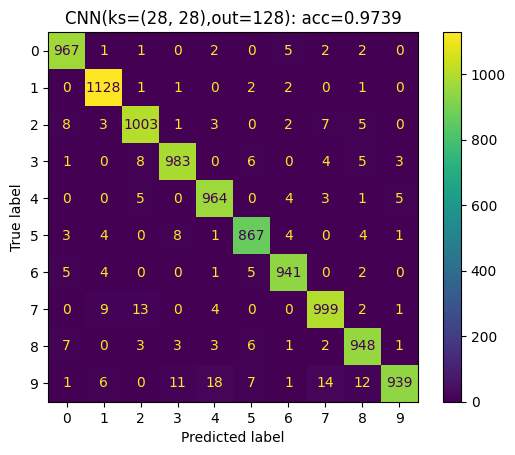

In [177]:
from sklearn.metrics import ConfusionMatrixDisplay
def confustion_mat():
    
    arr_y = []
    arr_yh = []
    for x, y in val_loader:
        logits = teacher_model(x)
        yh = torch.argmax(logits, dim=1)
        
        arr_y.extend(y.numpy().tolist())
        arr_yh.extend(yh.numpy().tolist())
    
    
    
    ConfusionMatrixDisplay.from_predictions(arr_y, arr_yh)
    plt.title(f"{teacher_model}: acc={teacher_acc:.4f}")
    
confustion_mat()

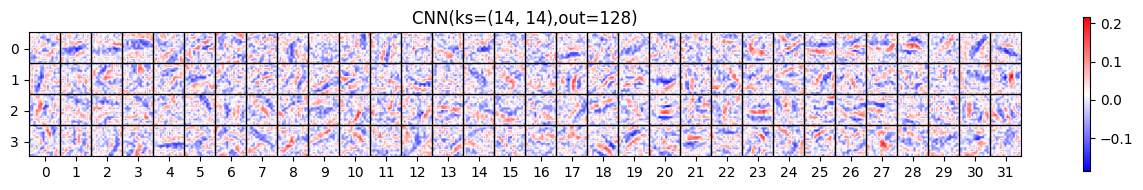

In [11]:
def viz_filter(weight):
    total = weight.shape[0]
    
    kernel_size = weight.shape[2]
    
    filters = weight.reshape((total, kernel_size, kernel_size))
    
    ncols = 32
    nrows = total // ncols 

    plt.figure(figsize=(ncols*0.5, nrows*0.5))
    plt.title(f"{teacher_model}")
    plt.imshow(
        zennit.image.gridify(filters, shape=(nrows, ncols)),
        cmap="bwr"
    )
    
    plt.xticks(
        np.arange(0, ncols*kernel_size, kernel_size)+ kernel_size // 2,
        np.arange(ncols)
    )

    plt.yticks(
        np.arange(0, nrows*kernel_size, kernel_size)+ kernel_size // 2,
                np.arange(nrows)
    )

    for i in range(1, ncols):
        plt.axvline(kernel_size*i-0.5, color="k", lw=1)
        
        
    for i in range(1, nrows):
        plt.axhline(kernel_size*i-0.5, color="k", lw=1)
        
    plt.colorbar(location="right")

    
viz_filter(teacher_model.conv1.weight.detach().cpu().numpy())

# Explaining

tensor(18.7501, grad_fn=<MaxBackward1>)


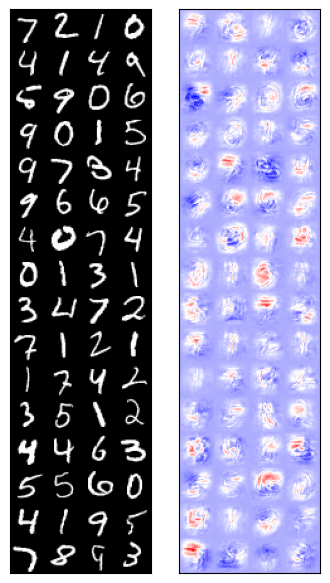

In [12]:
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

# low, high = 0, 1
# MAIN_TRANSFORM.transforms[1](torch.tensor([[[[[0.0]]] * 1], [[[[1.0]]] * 1]]))

composite = EpsilonGammaBox(low=low, high=high)


def explain():
    x, y = next(iter(val_loader))
    
    with Gradient(model=teacher_model, composite=composite) as attributor:
        logits, heatmaps = attributor.forward(x, lambda logits: F.one_hot(y, num_classes=10) * logits)
        print((logits * F.one_hot(y)).max())
    plt.figure(figsize=(4, 2*8))
    plt.subplot(1, 2, 1)
    plt.imshow(
        zennit.image.gridify(x.numpy(), shape=(16, 4)),
        cmap="gray"
    ) 
    plt.xticks([]); plt.yticks([])
    plt.subplot(1, 2, 2)
    plt.imshow(
        zennit.image.gridify(heatmaps.numpy(), shape=(16, 4)),
        cmap="bwr"
    )   
    plt.xticks([]); plt.yticks([])

        
explain()

# Which Filters are important for `4, 9`?

In [23]:
CONSIDERED_CLASSES = [4, 9]

CONSIDERED_LAYER = "act1"

CONSIDERED_MODULE = getattr(teacher_model, CONSIDERED_LAYER)

SEED = 1

NUM_SPATIAL_LOCATIONS_SAMPLING = 10


LOGIT_MODIFIER = attributors.LogOddEvidence(CONSIDERED_CLASSES)

## Buidling Subset for the Considered Classes

In [24]:
def build_subclasses_loader(considered_classes, samples_per_class, seed=SEED):
    
    
    train_ds = MNIST(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )
    
    np.random.seed(seed)

    train_subset = Subset(
        train_ds,
        indices=datasets.selected_subset_samples_for_classes(
            train_ds.targets,
            considered_classes,
            samples_per_class=samples_per_class,
        )
    )

    
    val_ds = MNIST(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )
        
    val_subset = Subset(val_ds, indices=np.argwhere(np.isin(val_ds.targets.numpy(), considered_classes)).reshape(-1))
       
    
    return train_subset, val_subset

SAMPLES_PER_CLASS  = 5000

train_subset, val_subset = build_subclasses_loader(CONSIDERED_CLASSES, samples_per_class=SAMPLES_PER_CLASS)

In [25]:
@torch.no_grad()
def sanitycheck():
    for x, y in DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE):        
        assert np.isin(y.numpy(), CONSIDERED_CLASSES).all()
        
    print("Sanity Check Passed!")
sanitycheck()

Sanity Check Passed!


## Visualizing Important Filters

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:13<00:00, 11.31it/s]


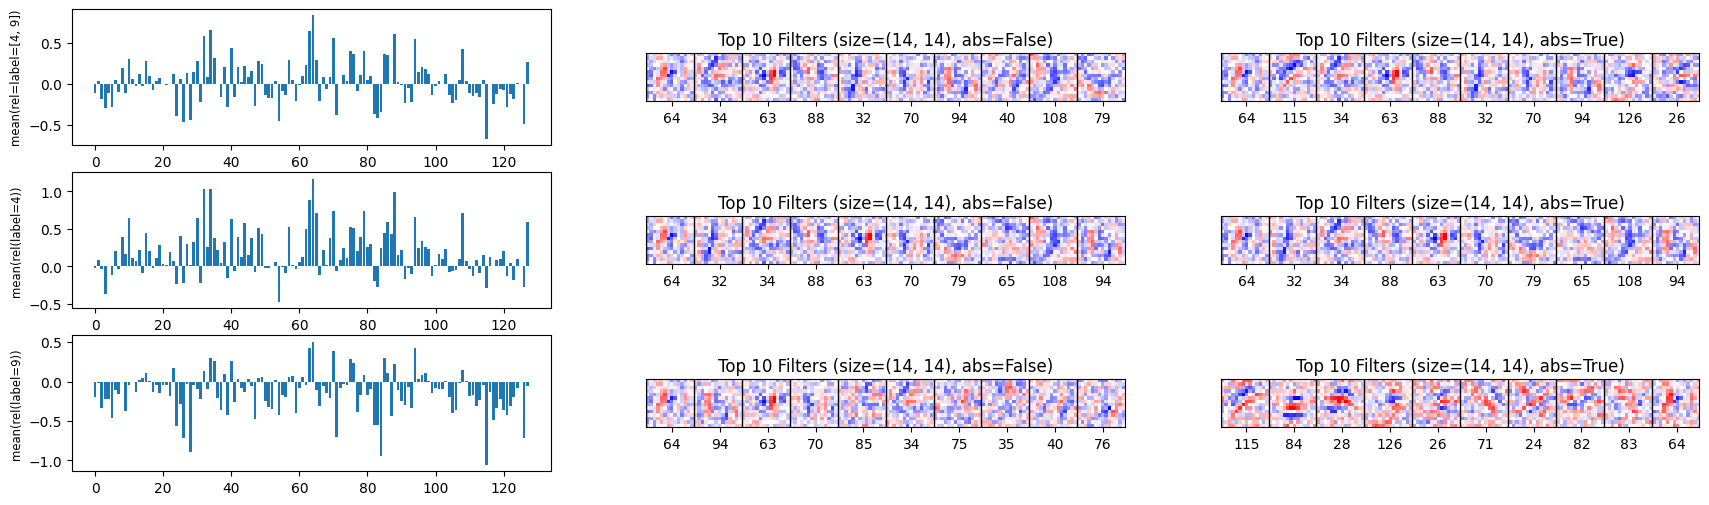

In [26]:
def viz_selected_filters(critier, k=10, absolute=False):
    nrows = 1
    ncols = k
    
    if absolute:
        critier = np.abs(critier)
        
    filters_indices = np.argsort(-critier)[:k]
    
    filters = teacher_model.conv1.weight[filters_indices, ].detach().numpy()
    
    ks = filters.shape[2]

    plt.imshow(
        zennit.image.gridify(filters, shape=(nrows, ncols)),
        cmap="bwr"
    )

    for i in range(ncols):
        plt.axvline(i*ks-0.5, ls="-", lw=1, color="k")
        
    plt.title(f"Top {k} Filters (size={ks, ks}, abs={absolute})")
    plt.yticks([])
    ticks = np.arange(k) * ks + 7
    plt.xticks(ticks, filters_indices)
    
def viz_important_filters():
    
    arr_rel = []
    arr_label = []
    
    module = getattr(teacher_model, CONSIDERED_LAYER)
    for x, y in tqdm(DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)):
        assert (np.isin(y, [CONSIDERED_CLASSES])).all()

        try:
            
            module, hook = utils.interceptor.attach_hook_intercept_module(module)
            with Gradient(model=teacher_model, composite=composite) as attributor:
                _ = attributor.forward(x, lambda logits: LOGIT_MODIFIER(logits))

            act = utils.interceptor.get_output(module)
            rel = act.grad.detach()
            rel = rel.flatten(start_dim=2).sum(dim=2).numpy()
            
            arr_rel.append(rel)
            arr_label.extend(y.tolist())


        finally:
            hook.remove()
            
    arr_rel = np.vstack(arr_rel)
    arr_label = np.array(arr_label)
    
    nrows = len(CONSIDERED_CLASSES) + 1
    ncols = 3
    
    ticks = np.arange(arr_rel.shape[1])
    
    plt.figure(figsize=(7*ncols, nrows*2))
    
    plt.subplot(nrows, ncols, 1)
    
    global_mean = arr_rel.mean(axis=0)
    plt.bar(ticks, global_mean)
    plt.ylabel(f"mean(rel=label={CONSIDERED_CLASSES})", fontsize="small")
    
    plt.subplot(nrows, ncols, 2)
    viz_selected_filters(global_mean, absolute=False)
    
    plt.subplot(nrows, ncols, 3)
    viz_selected_filters(global_mean, absolute=True)
    for ix, label in enumerate(CONSIDERED_CLASSES):
        plt.subplot(nrows, ncols, (ix+1)*ncols+1)
        plt.ylabel(f"mean(rel(label={label}))", fontsize="small")
        selected = arr_label == label
        
        class_mean = arr_rel[selected, :].mean(axis=0)
        plt.bar(ticks, class_mean)
        
        plt.subplot(nrows, ncols, (ix+1)*ncols+2)

        viz_selected_filters(class_mean, absolute=False)
        
        plt.subplot(nrows, ncols, (ix+1)*ncols+3)
        viz_selected_filters(class_mean, absolute=True)


    return arr_rel

CONSIDERED_FILTER_RELEVANCE = viz_important_filters()

In [27]:
def construct_filter_based_bases(rel):
    
    _, d = rel.shape
    
    critier = np.mean(rel, axis=0)
    abs_critier = np.abs(critier)
    
    U = np.eye(d)[:, np.argsort(-critier)]
    Uabs = np.eye(d)[:, np.argsort(-abs_critier)]
    
    
    np.testing.assert_allclose(np.sum(U, axis=0), 1)
    np.testing.assert_allclose(np.sum(Uabs, axis=0), 1)

    assert U[64, 0]==1 and U[34, 1] == 1
    assert Uabs[64, 0]==1 and Uabs[115, 1] == 1

    return U, Uabs

U_lrp_ranking, U_lrp_abs_ranking = construct_filter_based_bases(CONSIDERED_FILTER_RELEVANCE)

In [28]:
def construct_fh_hook_projection(U): 

    A = torch.from_numpy(U @ U.T).float().unsqueeze(2).unsqueeze(3)
    mean = 0
    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        return F.conv2d(output - mean, A) + mean

    return fh

def compute_auroc(U, verbose=False):
    layer = "act1"
  
    dl = DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)
    
    try:
        module = getattr(teacher_model, layer)
        
        hook = module.register_forward_hook(construct_fh_hook_projection(U))
        
        auroc, _ = metrics.auroc(teacher_model, dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)
        
        if verbose:
            print(f"auroc={auroc:.4f}")
    finally:
        hook.remove()
        
    return auroc

compute_auroc(U_lrp_ranking[:, :10])

0.9730329513549805

In [29]:
compute_auroc(U_lrp_abs_ranking[:, :10])

0.9929312467575073

In [30]:
teacher_auroc, _ = metrics.auroc(
    teacher_model,
    DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
    classes=CONSIDERED_CLASSES,
    device="cpu",
    should_convert_auroc=True
)
teacher_auroc

0.9998829364776611

# Build Basis

In [31]:
def build_basis():
    
#     module = teacher_model.act1

#     considered_classes = CONSIDERED_CLASSES
    
#     logit_mod = attributors.LogOddEvidence(considered_classes)

    arr_act = []
    
    arr_ctx = []
    for x, y in tqdm(DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)):
        assert (np.isin(y, [CONSIDERED_CLASSES])).all()

        try:
            
            module, hook = utils.interceptor.attach_hook_intercept_module(CONSIDERED_MODULE)
            with Gradient(model=teacher_model, composite=composite) as attributor:
                _ = attributor.forward(x, lambda logits: LOGIT_MODIFIER(logits))

            act = utils.interceptor.get_output(module)
            rel = act.grad

            ctx = torch.where(act.abs() > 0, rel / act, 0)
            
            act, ctx = utils.subsample_tensors(
                act.detach().numpy(),
                ctx.detach().numpy(),
                num_locations=NUM_SPATIAL_LOCATIONS_SAMPLING
            )

            arr_act.append(act)
            arr_ctx.append(ctx)

        finally:
            hook.remove()
            
    arr_act = np.vstack(arr_act)

    mean = np.mean(arr_act, axis=0)

    arr_act = arr_act 
    
    arr_ctx = np.vstack(arr_ctx)
    
    arr_act_centerd = arr_act - mean
    eigvals, eigvecs = np.linalg.eigh(arr_act_centerd.T @ arr_act_centerd / arr_act.shape[0])
    
    Upca = np.copy(eigvecs[:, ::-1])
    eigvals = np.copy(eigvals[::-1])
        
    torch.manual_seed(1)
    prca_abs = bases.PRCAAbs(alias="prca-abs", centering=False)
    
    prca_abs.fit(arr_act, arr_ctx, mean=mean)
    
    Uprca = prca_abs.artifact["eigvecs"]

    np.save("./tmp/Upca.npy", Upca)
    np.save("./tmp/Uprca.npy", Uprca)
    np.save("./tmp/mean.npy", mean)
    np.save("./tmp/arr_act_centered.npy", arr_act_centerd)
    
    return Upca, Uprca, eigvals, arr_act

# Upca, Uprca, eigvals, arr_act = build_basis()

[mode=abs,beta=0.0,device=cpu]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [12:34<00:00,  5.89s/it]


In [22]:
raise

RuntimeError: No active exception to reraise

In [32]:
def load():
    Upca = np.load("./tmp/Upca.npy")
    Uprca = np.load("./tmp/Uprca.npy")
    mean = np.load("./tmp/mean.npy")

    arr_act_centered = np.load("./tmp/arr_act_centered.npy")

    return Upca, Uprca, mean, arr_act_centered

Upca, UPrca, mean, arr_act_centered = load()

In [33]:
eigvals, eigvecs = np.linalg.eigh(np.cov(arr_act_centered.T))

eigvals =  eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

In [34]:
eigvals.shape

(128,)

In [35]:
eigvals[:3]

array([1.69849211, 1.60732024, 1.26040106])

In [36]:
eigvecs[:, 0].dot(Upca[:, 1])

-3.279156862712185e-07

In [37]:
((arr_act_centered @ eigvecs[:, 0])).std()  ** 2

1.698475126303314

In [38]:
eigvals[0]

1.6984921112244276

## Comparison between Bases

Scaling:
- PCA: $\sqrt{\lambda_i} = \text{std}(z_i)$ 
- PCA: $\text{std}(z_i)$ 

In [39]:
def get_basis(name):
    
    if name == "pca":
        U = Upca
    elif name == "prca":
        U = Uprca
    elif name == "rel":
        U = U_lrp_ranking
    elif name == "rel-abs":
        U = U_lrp_abs_ranking
    else:
        raise ValueError(f"`{name}` doesn't exist")
    
    z = arr_act_centered @ U
    scaling = (z).std(axis=0)
    
    assert scaling.shape == (U.shape[0],)
    
    # sanity check
    np.testing.assert_allclose(
        (z / scaling).std(axis=0),
        1, 
        atol=1e-5
    )
    
    return U,  1/scaling

get_basis("prca")

(array([[-0.06724928, -0.04457838,  0.01567518, ..., -0.05901391,
          0.09224035,  0.01249589],
        [-0.08426042, -0.03225379,  0.08975364, ..., -0.00782962,
         -0.22326468, -0.14188272],
        [-0.07734933,  0.06540602,  0.15237892, ...,  0.02560272,
          0.05474927, -0.14142899],
        ...,
        [-0.09928352, -0.06646787,  0.16090508, ...,  0.06542734,
         -0.07204713,  0.14850862],
        [-0.05687121, -0.0327482 , -0.0735368 , ...,  0.0329486 ,
         -0.04766596,  0.08705992],
        [-0.02211886, -0.19923258,  0.07466853, ...,  0.08690308,
          0.05438737, -0.12405394]], dtype=float32),
 array([1.1284186 , 1.4205207 , 0.87824315, 1.0303947 , 0.98722607,
        1.1054765 , 1.0859615 , 1.1312071 , 1.2472941 , 1.2852683 ,
        1.429815  , 1.4131223 , 1.4632268 , 1.5250996 , 1.6058683 ,
        1.6038618 , 1.715118  , 1.7394785 , 1.7818698 , 1.8881631 ,
        1.8111736 , 1.9511998 , 2.0763173 , 2.325754  , 2.1102464 ,
        2.2454627 

## Basis Comparision of PCA, PRCA

In [40]:
def estimate_auroc_bases():
    
    
    arr_rows = []
    for basis in ['pca', 'prca', 'rel', 'rel-abs']:
        U, scaling = get_basis(basis)

        for k in tqdm(list(range(1, 10+1)) + [32, 64, 128]):
            auroc = compute_auroc(U[:, :k])
            
            arr_rows.append(
                dict(
                    name=basis,
                    k=k,
                    auroc=auroc
                )
            )
    return pd.DataFrame(arr_rows)

df_basis_comparison = estimate_auroc_bases()


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:08<00:00,  1.45it/s]


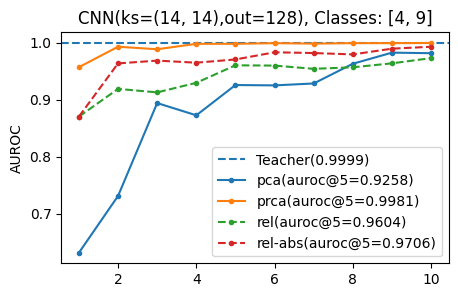

In [43]:
def viz(df):
    plt.figure(figsize=(5, 3))
    basis_names = df.name.unique()
        
    plt.title(f"{teacher_model}, Classes: {CONSIDERED_CLASSES}")
    plt.axhline(teacher_auroc, ls="--", label=f"Teacher({teacher_auroc:.4f})")
    nn = 10
    for name in basis_names:
        _df = df[df.name == name]

        auroc_at_5 = _df[_df.k==5].auroc.values[-1]
        
        plt.plot(
            _df.k[:nn],
            _df.auroc[:nn],
            label=f"{name}(auroc@5={auroc_at_5:.4f})",
            marker=".",
            ls="--" if "rel" in name else "-"
        )
        
    plt.legend()
    plt.ylabel("AUROC")
        
viz(df_basis_comparison)

In [47]:
df_basis_comparison[df_basis_comparison.k==1]

,name,k,auroc
0,pca,1,0.631898
13,prca,1,0.957116
26,rel,1,0.870460
39,rel-abs,1,0.870460


# Training Approximator

In [44]:
from copy import deepcopy

In [45]:
utils.deactivate_requires_grad(teacher_model)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name    | Type         | Params
-----------------------------------------
0 | approx  | Approximator | 25.4 K
1 | teacher | CNN          | 313 K 
-----------------------------------------
199       Trainable params
338 K     Non-trainable params
338 K     Total params
1.355     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

[batch_ix=  0] mse_loss=34.3153, crossent=0.0000
[batch_ix=  0] mse_loss=4.0036, crossent=0.0000
[batch_ix=  0] mse_loss=1.7898, crossent=0.0000
[batch_ix=  0] mse_loss=1.8638, crossent=0.0000
[batch_ix=  0] mse_loss=1.3843, crossent=0.0000
[batch_ix=  0] mse_loss=1.3601, crossent=0.0000
[batch_ix=  0] mse_loss=1.1130, crossent=0.0000
[batch_ix=  0] mse_loss=1.0722, crossent=0.0000
[batch_ix=  0] mse_loss=0.8049, crossent=0.0000
[batch_ix=  0] mse_loss=1.1051, crossent=0.0000
[batch_ix=  0] mse_loss=0.8814, crossent=0.0000
[batch_ix=  0] mse_loss=0.6394, crossent=0.0000
[batch_ix=  0] mse_loss=0.6252, crossent=0.0000
[batch_ix=  0] mse_loss=0.6242, crossent=0.0000
[batch_ix=  0] mse_loss=0.3453, crossent=0.0000
[batch_ix=  0] mse_loss=0.4134, crossent=0.0000
[batch_ix=  0] mse_loss=0.4344, crossent=0.0000
[batch_ix=  0] mse_loss=0.2863, crossent=0.0000
[batch_ix=  0] mse_loss=0.2703, crossent=0.0000
[batch_ix=  0] mse_loss=0.2863, crossent=0.0000
[batch_ix=  0] mse_loss=0.1742, crossen

`Trainer.fit` stopped: `max_epochs=50` reached.


Time Took: 0:00:04.386010 mins
basis=pca(Approx(k=1,w=torch.Size([1, 1, 14, 14]))); trained with lambda_mse=1.0, lambda_crossent=0.0
(train): auroc=0.7110
(val  ): auroc=0.6678


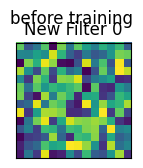

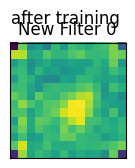

In [152]:
class Approximator(nn.Module):
    def __init__(self, U, scaling, mean, input_channels=1):
        super().__init__()
    
        d, k = U.shape
        
        assert len(scaling) == k
        
        self.teacher_conv1 = deepcopy(teacher_model.conv1)
        utils.deactivate_requires_grad(self.teacher_conv1)
        
        self.U = torch.from_numpy(U).T.unsqueeze(2).unsqueeze(3).float()
        self.scaling = torch.from_numpy(scaling).float().reshape((1, -1, 1, 1))
        self.UT = torch.from_numpy(U).unsqueeze(2).unsqueeze(3).float()
        self.k = k
        dout,_, kernel_size, _ = teacher_model.conv1.weight.shape
        
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=k,
            kernel_size=(kernel_size, kernel_size), padding="valid",
        )
        
        self.act = nn.ReLU()
#         self.act = nn.LeakyReLU()
        
        self.conv2 = nn.Conv2d(
            in_channels=k, out_channels=k,
            kernel_size=(1, 1), padding="valid",
#             bias=False
        )
        self.conv2.bias = nn.Parameter(torch.Tensor([-6.]))

        self.mean = torch.from_numpy(mean).reshape((1, -1, 1, 1))

   
        
    def forward(self, x):
#         x = self.teacher_conv1(x)
        
        out = self.conv1(x)
        
        out = self.act(out)
        out = self.conv2(out) 
        return out

    
    def __str__(self):
        return f"Approx(k={self.k},w={self.conv1.weight.shape})"


class ApproximatorModelWrapper(pl.LightningModule):
    def __init__(self, approx, teacher, lambda_mse=1, lambda_crossent=1, verbose=False, ):
        super().__init__()

        self.approx = approx
        self.teacher = teacher
        
        self.verbose = verbose
        
        self.lambda_mse = lambda_mse
        self.lambda_crosse_ent = lambda_crossent
        

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.approx.parameters(), lr=1e-3, weight_decay=0.0)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
                
        assert np.isin(y.numpy(), CONSIDERED_CLASSES).all()
        
        
        with torch.no_grad():
            a = self.teacher.forward_feat(x)
            au = F.conv2d(a - self.approx.mean, self.approx.U)
        
            
            b, c, h, w = au.shape
                       
        spatial_scaling = 1/(h*w)
        ah = self.approx(x)
        
        diff = (au-ah)**2
        diff = F.relu(diff - 2)
        loss = (diff) * spatial_scaling
        
        loss = loss.flatten(start_dim=1)
        
        loss = loss.sum(dim=1) 
        mse_loss = self.lambda_mse * loss.mean()
        
        out = F.conv2d(ah, self.approx.UT).flatten(start_dim=1)
        
        logits = self.teacher.lin2(out)
        
        crossent = self.lambda_crosse_ent*F.cross_entropy(logits, y)
        
        # scaling
        loss = mse_loss + crossent
        
        if batch_idx == 0 and self.verbose:
            print(f"[batch_ix={batch_idx:3d}] mse_loss={mse_loss.detach().numpy():.4f}, crossent={crossent:.4f}")
        
        return loss
    
    
class CombinedModule(nn.Module):
    def __init__(self, approximator, teacher=teacher_model, input_channels=1):
        super().__init__()
        
        self.approximator = approximator
        self.teacher = teacher
        
        UT = self.approximator.U.squeeze(2, 3)
                
        A = UT.T
                
        self.A = A.unsqueeze(2).unsqueeze(3)
        self.inverse_scaling = 1/self.approximator.scaling
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        
    def forward(self, x):
        a = self.approximator(x)
        
        au = F.conv2d(a, self.A)
        au = au + self.approximator.mean
        
        au = au.flatten(start_dim=1)
        
        x = self.teacher.lin2(au)

        return x

def viz_filter_approx(approx, title):
    weight = approx.conv1.weight.detach().numpy()
    
    ncols = weight.shape[0]

    nrows = 1
    plt.figure(figsize=(1.5*ncols, 1.5*nrows))
    
    plt.suptitle(title, y=1.1)
    
    for i in range(ncols):
        plt.subplot(1, ncols, i+1)
        plt.title(f"New Filter {i}")
        plt.imshow(weight[i, ].squeeze())
        plt.xticks([]); plt.yticks([])
        
def train_approximator(basis_name, teacher, lambda_mse, lambda_crossent, epochs=5, device="cpu", verbose=False):
    pl.seed_everything(SEED)

    U, scaling = get_basis(basis_name)

 
    torch.manual_seed(SEED)
    approximator = Approximator(
        U[:, :TOTAL_COMPONENT_SELECTED],
        scaling[:TOTAL_COMPONENT_SELECTED],
        mean
    )
    viz_filter_approx(approximator, "before training")
    
    dl = DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True)
    
    start_time = datetime.now()
    

    trainer = pl.Trainer(
        accelerator=device, max_epochs=epochs, deterministic=True,
#         overfit_batches=1
    )

    trainer.fit(
        ApproximatorModelWrapper(approximator, teacher, verbose=verbose, lambda_mse=lambda_mse, lambda_crossent=lambda_crossent), dl)

    print("Time Took:", (datetime.now() - start_time) / 60, "mins")

    print(f"basis={basis_name}({approximator}); trained with lambda_mse={lambda_mse}, lambda_crossent={lambda_crossent}")
    
    for sn, subset in [
        ("train", train_subset),
        ("val", val_subset)
    ]:
    
        auroc, _ = metrics.auroc(
            CombinedModule(approximator),
            DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
            classes=CONSIDERED_CLASSES,
            device="cpu", 
            should_convert_auroc=True
        )
        print(f"({sn:5s}): auroc={auroc:.4f}")
    
    viz_filter_approx(approximator, "after training")

    return approximator

    
TOTAL_COMPONENT_SELECTED = 1

approx_pca = train_approximator(
    "pca",
    teacher=teacher_model,
    lambda_mse=1.0,
    lambda_crossent=0.0,
    verbose=True,
    epochs=50
)

Comparision
- no scaling loss, no scaling infer: (val  ): auroc=0.8770 (le=1e-3)
- scaling loss, scaling infer: (val  ): auroc=0.5486; 
- scaling loss, no scaling infer: (val  ): auroc=0.7530
- no scaling los, scaling infer: (val  ): auroc=0.6030


Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name    | Type         | Params
-----------------------------------------
0 | approx  | Approximator | 25.4 K
1 | teacher | CNN          | 313 K 
-----------------------------------------
199       Trainable params
338 K     Non-trainable params
338 K     Total params
1.355     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

[batch_ix=  0] mse_loss=33.3178, crossent=0.0000
[batch_ix=  0] mse_loss=1.4535, crossent=0.0000
[batch_ix=  0] mse_loss=0.6936, crossent=0.0000
[batch_ix=  0] mse_loss=0.6897, crossent=0.0000
[batch_ix=  0] mse_loss=0.5246, crossent=0.0000
[batch_ix=  0] mse_loss=0.4152, crossent=0.0000
[batch_ix=  0] mse_loss=0.3950, crossent=0.0000
[batch_ix=  0] mse_loss=0.3083, crossent=0.0000
[batch_ix=  0] mse_loss=0.1831, crossent=0.0000
[batch_ix=  0] mse_loss=0.3714, crossent=0.0000
[batch_ix=  0] mse_loss=0.2649, crossent=0.0000
[batch_ix=  0] mse_loss=0.1712, crossent=0.0000
[batch_ix=  0] mse_loss=0.2000, crossent=0.0000
[batch_ix=  0] mse_loss=0.2448, crossent=0.0000
[batch_ix=  0] mse_loss=0.0994, crossent=0.0000
[batch_ix=  0] mse_loss=0.0981, crossent=0.0000
[batch_ix=  0] mse_loss=0.1374, crossent=0.0000
[batch_ix=  0] mse_loss=0.1223, crossent=0.0000
[batch_ix=  0] mse_loss=0.0849, crossent=0.0000
[batch_ix=  0] mse_loss=0.0856, crossent=0.0000
[batch_ix=  0] mse_loss=0.0738, crossen

`Trainer.fit` stopped: `max_epochs=50` reached.


Time Took: 0:00:05.384033 mins
basis=prca(Approx(k=1,w=torch.Size([1, 1, 14, 14]))); trained with lambda_mse=1.0, lambda_crossent=0.0
(train): auroc=0.7329
(val  ): auroc=0.7365


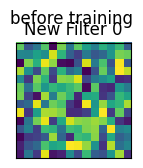

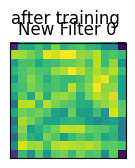

In [153]:
approx_prca = train_approximator(
    "prca",
    teacher=teacher_model,
    lambda_mse=1.0,
    lambda_crossent=0.0,
    verbose=True,
    epochs=50
)

(train): auroc=0.8100
(val  ): auroc=0.8106


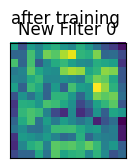

In [147]:
def ano(approximator):
    for sn, subset in [
        ("train", train_subset),
        ("val", val_subset)
    ]:
    
        auroc, _ = metrics.auroc(
            CombinedModule(approximator),
            DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
            classes=CONSIDERED_CLASSES,
            device="cpu", 
            should_convert_auroc=True
        )
        print(f"({sn:5s}): auroc={auroc:.4f}")
    
    viz_filter_approx(approximator, "after training")
    
ano(approx_prca)

Hidge Loss
- `dif-1` (val  ): auroc=0.8622
- `dif-2` (val  ): auroc=0.8415


In [ ]:
df_basis_comparison[df_basis_comparison.k==TOTAL_COMPONENT_SELECTED]

In [ ]:
raise

# Error Analysis


0it [00:00, ?it/s]
3it [00:00, 28.03it/s]
9it [00:00, 43.42it/s]
14it [00:00, 38.45it/s]
21it [00:00, 48.12it/s]
27it [00:00, 50.04it/s]
33it [00:00, 51.12it/s]
40it [00:00, 54.61it/s]
46it [00:00, 54.85it/s]
53it [00:01, 56.99it/s]
59it [00:01, 57.08it/s]
65it [00:01, 56.73it/s]
71it [00:01, 54.99it/s]
78it [00:01, 57.76it/s]
84it [00:01, 54.62it/s]
91it [00:01, 56.70it/s]
97it [00:01, 56.20it/s]
103it [00:01, 54.50it/s]
110it [00:02, 57.08it/s]
117it [00:02, 58.60it/s]
124it [00:02, 59.78it/s]
130it [00:02, 59.31it/s]
137it [00:02, 60.23it/s]
144it [00:02, 55.06it/s]
150it [00:02, 51.95it/s]
157it [00:02, 53.56it/s]

0it [00:00, ?it/s]
6it [00:00, 53.24it/s]
13it [00:00, 58.90it/s]
20it [00:00, 61.60it/s]
27it [00:00, 63.47it/s]
34it [00:00, 64.57it/s]
41it [00:00, 64.25it/s]
48it [00:00, 63.86it/s]
55it [00:00, 62.35it/s]
62it [00:01, 60.68it/s]
69it [00:01, 60.65it/s]
76it [00:01, 60.88it/s]
83it [00:01, 60.75it/s]
90it [00:01, 61.59it/s]
97it [00:01, 53.56it/s]
103it [00:01, 51.8

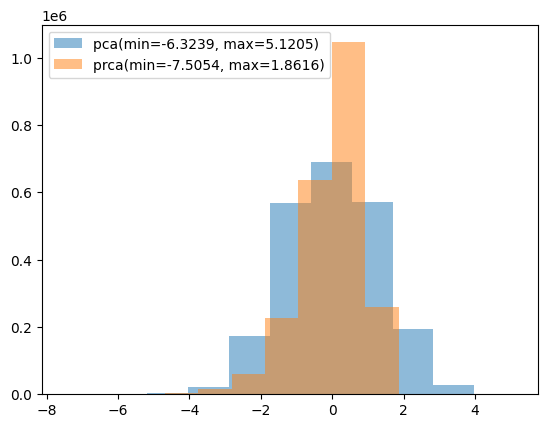

In [148]:
def histogram():
    
    dl = DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True)
    
    
    for basis_name in ["pca", "prca"]:
        arr_z = []
 
        U,  _ = get_basis(basis_name)
        U = torch.from_numpy(U[:, :TOTAL_COMPONENT_SELECTED].T).unsqueeze(2).unsqueeze(3).float()
        act_mean = torch.from_numpy(mean).reshape((1, -1, 1, 1)).float()

        for bix, (x, _) in tqdm(enumerate(dl)):

            out = teacher_model.forward_feat(x)

            z = F.conv2d(out-act_mean, U)

            arr_z.extend(z.reshape(-1).numpy().tolist())

        min, max = np.min(arr_z), np.max(arr_z)
        plt.hist(arr_z, label=f"{basis_name}(min={min:.4f}, max={max:.4f})", alpha=0.5)
    plt.legend()
histogram()


0it [00:00, ?it/s]
4it [00:00, 39.78it/s]
10it [00:00, 49.59it/s]
17it [00:00, 57.71it/s]
23it [00:00, 58.30it/s]
29it [00:00, 57.25it/s]
37it [00:00, 62.55it/s]
44it [00:00, 57.81it/s]
50it [00:00, 54.44it/s]
56it [00:01, 49.20it/s]
62it [00:01, 49.29it/s]
69it [00:01, 53.38it/s]
75it [00:01, 49.85it/s]
81it [00:01, 51.06it/s]
87it [00:01, 50.38it/s]
93it [00:01, 52.39it/s]
99it [00:01, 51.79it/s]
105it [00:01, 50.73it/s]
111it [00:02, 48.81it/s]
116it [00:02, 47.98it/s]
121it [00:02, 47.02it/s]
127it [00:02, 48.93it/s]
133it [00:02, 51.63it/s]
139it [00:02, 53.42it/s]
145it [00:02, 54.45it/s]
157it [00:03, 51.60it/s]


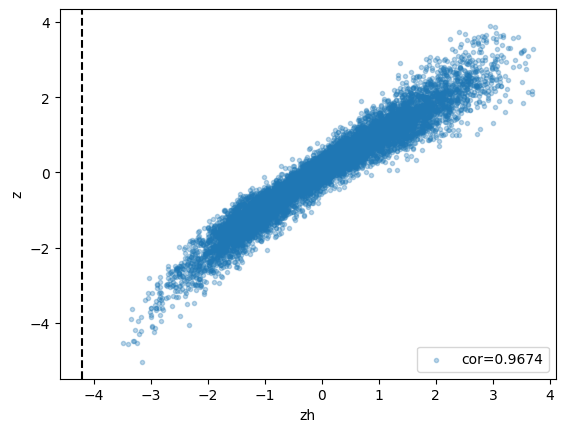

In [149]:
@torch.no_grad()
def ano(approximator):
    
    
    arr_z = []
    arr_zh = []
    dl = DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True)
    for bix, (x, _) in tqdm(enumerate(dl)):

        out = teacher_model.forward_feat(x)

        z = F.conv2d(out - approximator.mean, approximator.U)
        zh = approximator(x)

        arr_z.extend(z.reshape(-1).numpy().tolist())
        arr_zh.extend(zh.reshape(-1).numpy().tolist())

#     _, bins, _ = plt.hist(arr_z, label="Original Z", alpha=0.5)
#     plt.hist(arr_zh, label="Approximated Z", bins=bins, alpha=0.5)
    
    plt.scatter(
        arr_zh[:10000], arr_z[:10000], marker=".", alpha=0.3,
        label=f"cor={np.corrcoef(arr_zh, arr_z)[0, 1]:.4f}"
    )
    plt.xlabel("zh")
    plt.ylabel("z")
    plt.legend()
    plt.axvline(approximator.conv2.bias[0], label="bias", ls="--", color="k")
    
ano(approx_pca)


0it [00:00, ?it/s]
6it [00:00, 54.18it/s]
13it [00:00, 61.34it/s]
20it [00:00, 59.26it/s]
27it [00:00, 61.11it/s]
34it [00:00, 60.62it/s]
41it [00:00, 57.50it/s]
47it [00:00, 56.85it/s]
53it [00:00, 52.72it/s]
59it [00:01, 48.90it/s]
65it [00:01, 50.88it/s]
71it [00:01, 51.84it/s]
77it [00:01, 48.94it/s]
82it [00:01, 49.09it/s]
88it [00:01, 51.06it/s]
95it [00:01, 55.38it/s]
101it [00:01, 55.48it/s]
107it [00:01, 54.96it/s]
113it [00:02, 53.94it/s]
119it [00:02, 53.57it/s]
125it [00:02, 53.73it/s]
131it [00:02, 55.31it/s]
137it [00:02, 56.06it/s]
144it [00:02, 58.95it/s]
150it [00:02, 58.93it/s]
157it [00:02, 53.95it/s]


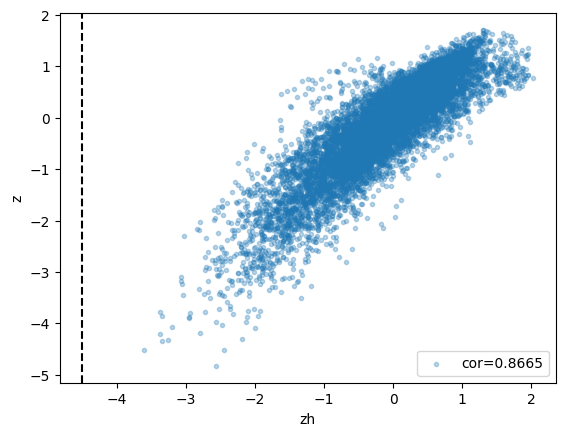

In [150]:
ano(approx_prca)

In [ ]:
approx_prca.conv2.bias

In [ ]:
print(f"Finished at {datetime.now()}")

Things to try
- (doesn't help) wegit decay? (PRCA: w/o 0.96, w/ ...)
- error analysis on which component we made an error.

In [ ]:
raise

# TODO
- scaling  the projected 
- figure projection error before training

In [ ]:


viz_filter_approx(approx_prca)

approx_prca = train_approximator(approx_prca, teacher=teacher_model)

viz_filter_approx(approx_prca)

In [ ]:
print(f"(train) k={k}", metrics.auroc(
    CombinedModule(approx_pca),
    DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
    classes=CONSIDERED_CLASSES,
    device="cpu", 
    should_convert_auroc=True
)[0])

print(f"(val  ) k={k}", metrics.auroc(
    CombinedModule(approx_pca),
    DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
    classes=CONSIDERED_CLASSES,
    device="cpu", 
    should_convert_auroc=True
)[0])


df[(df.name == "pca") & (df.k == k)]

In [ ]:
print(f"(train) k={k}", metrics.auroc(
    CombinedModule(approx_prca),
    DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
    classes=CONSIDERED_CLASSES,
    device="cpu",
    should_convert_auroc=True
)[0])

print(f"(val)k={k}", metrics.auroc(
    CombinedModule(approx_prca),
    DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
    classes=CONSIDERED_CLASSES,
    device="cpu",
    should_convert_auroc=True
)[0])

df[(df.name == "prca") & (df.k == k)]

In [ ]:
# (val)k=1 0.8703375458717346 (w/ spatial scaling)
# (val)k=1 0.8699040412902832 (uniform spatial scaling)
# (val)k=1 0.8699272871017456 (w/o spatial scaling)
# (val)k=1 0.8668127655982971 (w/ global scaling)
# 0.86...
# 0.8566486239433289
# 0.9400532841682434

In [ ]:
# raise

In [ ]:
def estimate_effect(arr_ks=[1, 2, 3, 4, 5]):
    rows = []
    for basis in ["pca", "prca"]:
        for with_scaling in [False]:
            U, scaling = get_basis(name=basis, with_scaling=with_scaling)
            
            for k in arr_ks:
                print(f"Basis={basis} (k={k})")

                approx = Approximator(U[:, :k], scaling[:k] if scaling is not None else None)
                approx = train_approximator(approx, teacher=teacher_model)
                auroc, _ = metrics.auroc(
                    CombinedModule(approx),
                    DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
                    classes=CONSIDERED_CLASSES,
                    device="cpu", 
                    should_convert_auroc=True
                )
                
                rows.append(dict(name=basis, k=k, with_scaling=with_scaling, auroc=auroc))
            
    return pd.DataFrame(rows)        
    
df_stats_w_scaling = estimate_effect()

In [ ]:
df_stats_w_scaling

In [ ]:
df

In [ ]:
def train_distill(epochs=5, device="cpu", k=10):

    kernel_size = teacher_model.conv1.weight.shape[2]
    
    _model = CNN(kernel_size=kernel_size, nhidden=k)
    
    pl.seed_everything(SEED)
    

    start_time = datetime.now()

    trainer = pl.Trainer(accelerator=device, max_epochs=epochs)

    train_subset_dl = DataLoader(train_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True)
    
    trainer.fit(ModelWrapper(_model), train_subset_dl)
    
    
    print("Time Took:", (datetime.now() - start_time) / 60, "mins")
    
    
    auroc, _ = metrics.auroc(
        _model,
        DataLoader(val_subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE),
        classes=CONSIDERED_CLASSES,
        device="cpu",
        should_convert_auroc=True
    )
    
    print(f"AUROC: {auroc:.4f}")
    
    viz_filter_approx(_model)
    
    return auroc, k
    
auroc_subset_from_scatch, from_scatch_k = train_distill(k=4, epochs=10*4)

In [ ]:
def viz(df, df_teacher):
    
    kernel_size = tuple(teacher_model.conv1.weight.shape[2:])
    colors = ["blue", "red"]
    
    plt.title(
        f"MSE Approx: considered_classes={CONSIDERED_CLASSES}, kernel_size={kernel_size}, nsamples_per_class={SAMPLES_PER_CLASS}")
    plt.ylabel("AUROC")
    
    
    
    plt.axhline(teacher_auroc, ls="-", color="k", label="Teacher")
    
    plt.axhline(auroc_subset_from_scatch, ls="--", color="k", label=f"From Scratch only Subclass (k={from_scatch_k})")
    for nix, name in enumerate(df_stats_w_scaling.name.unique()):
        
        
        _df_teacher = df_teacher[
            (df_teacher.k <= df_stats_w_scaling.k.max()) & (df_teacher.name == name)
        ]
        
        
        plt.plot(
            _df_teacher.k, _df_teacher.auroc, label=f"Teacher with {name}",
            color=colors[nix],
            ls="-.",
            marker="s"
        )
        
        for with_scaling in [False]:
            _df = df_stats_w_scaling[(df.name == name) & (df.with_scaling == with_scaling)]
            
            plt.plot(
                _df.k,
                _df.auroc,
                ls = "-" if with_scaling else "--",
                color=colors[nix],
                label=f"Student w/ {name}(scaling={with_scaling})",
                marker="."
            )
    plt.xticks(_df.k)
    plt.xlabel("Number of Components in Student")
    plt.legend()
viz(df_stats_w_scaling, df)